<a href="https://colab.research.google.com/github/actelleza-maker/Ciencia-de-datos-con-IA/blob/main/Copia_de_Challenge_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Challenge

Considera los datos `creditcard.csv`. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.


## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

# Entrenar un modelo con KMeans, separando la columna objetivo Class del resto de las columnas.

In [51]:
# Cargar librerias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn import datasets

from pprint import pprint

In [52]:
# Cargar datos

ccf_dat = pd.read_csv('/content/sample_data/creditcard.csv')

ccf_dat.head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [53]:

# Se seleccionan únicamente las columnas correspondientes a los componentes principales V1, V2, V3 y Amount, se desecha Time y el resto de combinaciones de PCA


ccf = ccf_dat[['V1', 'V2', 'V3', 'Amount', 'Class']]

ccf



,V1,V2,V3,Amount,Class
0,-1.359807,-0.072781,2.536347,149.62,0.0
1,1.191857,0.266151,0.166480,2.69,0.0
2,-1.358354,-1.340163,1.773209,378.66,0.0
3,-0.966272,-0.185226,1.792993,123.50,0.0
4,-1.158233,0.877737,1.548718,69.99,0.0
...,...,...,...,...,...
95157,1.142364,-1.090177,0.511068,106.00,0.0
95158,-2.145283,1.280406,0.014577,34.61,0.0
95159,-3.715715,3.870511,-1.525809,0.89,0.0
95160,-5.164795,4.510526,-0.994499,7.18,0.0


In [54]:
# Se eliminan los NaN values en ''Amount', 'V1', 'V2', 'V3" o 'Class' para graficación

ccf_clean = ccf.dropna(subset=['V1', 'V2', 'V3','Amount', 'Class'])

ccf_clean

,V1,V2,V3,Amount,Class
0,-1.359807,-0.072781,2.536347,149.62,0.0
1,1.191857,0.266151,0.166480,2.69,0.0
2,-1.358354,-1.340163,1.773209,378.66,0.0
3,-0.966272,-0.185226,1.792993,123.50,0.0
4,-1.158233,0.877737,1.548718,69.99,0.0
...,...,...,...,...,...
95156,-0.327858,0.966095,1.541728,2.97,0.0
95157,1.142364,-1.090177,0.511068,106.00,0.0
95158,-2.145283,1.280406,0.014577,34.61,0.0
95159,-3.715715,3.870511,-1.525809,0.89,0.0


In [55]:
# Se escalan, V1, V2, C3 y Amount

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ccf_clean.loc[:, 'AmountE'] = scaler.fit_transform(ccf_clean['Amount'].values.reshape(-1, 1))
ccf_clean.loc[:, 'V1E'] = scaler.fit_transform(ccf_clean['V1'].values.reshape(-1, 1))
ccf_clean.loc[:, 'V2E'] = scaler.fit_transform(ccf_clean['V2'].values.reshape(-1, 1))
ccf_clean.loc[:, 'V3E'] = scaler.fit_transform(ccf_clean['V3'].values.reshape(-1, 1))

ccf_clean

/tmp/ipykernel_835/2011639727.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_835/2011639727.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_835/2011639727.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_835/201

,V1,V2,V3,Amount,Class,AmountE,V1E,V2E,V3E
0,-1.359807,-0.072781,2.536347,149.62,0.0,0.007612,0.943114,0.792888,0.955424
1,1.191857,0.266151,0.166480,2.69,0.0,0.000137,0.986831,0.796587,0.892906
2,-1.358354,-1.340163,1.773209,378.66,0.0,0.019264,0.943139,0.779055,0.935292
3,-0.966272,-0.185226,1.792993,123.50,0.0,0.006283,0.949857,0.791661,0.935814
4,-1.158233,0.877737,1.548718,69.99,0.0,0.003561,0.946568,0.803263,0.929370
...,...,...,...,...,...,...,...,...,...
95156,-0.327858,0.966095,1.541728,2.97,0.0,0.000151,0.960794,0.804227,0.929185
95157,1.142364,-1.090177,0.511068,106.00,0.0,0.005393,0.985983,0.781783,0.901996
95158,-2.145283,1.280406,0.014577,34.61,0.0,0.001761,0.929657,0.807658,0.888899
95159,-3.715715,3.870511,-1.525809,0.89,0.0,0.000045,0.902751,0.835928,0.848263


In [56]:
import plotly.express as px


fig = px.scatter_ternary(ccf_clean,
                         a="V1E",
                         b="V2E",
                         c="V3E",
                         size="AmountE",
                         size_max=100,
                         color="AmountE")
fig.show()

### Preparación de los datos para K-Means

In [58]:
# Separar la columna objetivo 'Class' y usar las columnas escaladas
# Excluir 'Amount' original y usar 'AmountE', mismo proceso  para las V
X = ccf_clean.drop(['Class', 'Amount', 'V1', 'V2', 'V3'], axis=1)
y = ccf_clean['Class']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=40, stratify=y)

De forma arbitraria seleccionamos el valor del hiperparametro n_clusters=3

In [60]:
from sklearn.cluster import KMeans

# Re-initialize and fit KMeans model with the updated X_train
model = KMeans(n_clusters=3, random_state=42, n_init=10) # Added random_state for reproducibility and n_init
model.fit(X_train)

KMeans(n_clusters=3, n_init=10, random_state=42)

Se obtiene la inercia del modelo

In [61]:
model.inertia_

101.9419824836617

In [62]:
model.score(X_train)

-101.94198248366173

Centro de los clusters

In [63]:
model.cluster_centers_

array([[0.00497773, 0.98198098, 0.78984985, 0.89545953],
       [0.0038027 , 0.94466727, 0.79745495, 0.92475518],
       [0.03110219, 0.84339517, 0.78694454, 0.78308467]])

In [64]:
# Se obtienen los centroides
centroides_df = (pd.DataFrame(model.cluster_centers_)
.rename(columns={0:'V1', 1:'V2', 2:'V3', 3:'AmountE'}))

In [65]:
centroides_df

,V1,V2,V3,AmountE
0,0.004978,0.981981,0.789850,0.895460
1,0.003803,0.944667,0.797455,0.924755
2,0.031102,0.843395,0.786945,0.783085


In [66]:
fig = px.scatter_ternary(centroides_df,
                         a="V2",
                         b="V2",
                         c="V3")

fig


In [67]:
# Obtener parámetros del modelo

model.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': 42,
 'tol': 0.0001,
 'verbose': 0}

In [68]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

In [69]:
# Ver subconjunto de prueba

X_test

,AmountE,V1E,V2E,V3E
23470,0.003459,0.954240,0.798109,0.897676
10758,0.000307,0.960323,0.798601,0.951209
52382,0.000483,0.942534,0.808196,0.900560
19323,0.000137,0.949624,0.797666,0.946721
3992,0.001376,0.941375,0.789196,0.942618
...,...,...,...,...
91519,0.022641,0.939640,0.787223,0.920064
35845,0.000203,0.946102,0.801222,0.953130
87696,0.000137,0.961590,0.805459,0.913166
5502,0.007362,0.942062,0.794257,0.958659


In [70]:
# Probar el modelo

labels = model.predict(X_test)
labels

array([1, 1, 1, ..., 1, 1, 0], dtype=int32)

In [71]:
X_test['cluster'] = labels
X_test

,AmountE,V1E,V2E,V3E,cluster
23470,0.003459,0.954240,0.798109,0.897676,1
10758,0.000307,0.960323,0.798601,0.951209,1
52382,0.000483,0.942534,0.808196,0.900560,1
19323,0.000137,0.949624,0.797666,0.946721,1
3992,0.001376,0.941375,0.789196,0.942618,1
...,...,...,...,...,...
91519,0.022641,0.939640,0.787223,0.920064,1
35845,0.000203,0.946102,0.801222,0.953130,1
87696,0.000137,0.961590,0.805459,0.913166,1
5502,0.007362,0.942062,0.794257,0.958659,1


### Análisis de la distribución de `Class == 1` en cada cluster considerando una k arbitaria = 3

In [72]:
# Añadir la columna 'Class' real de y_test a X_test para el análisis
X_test_with_class = X_test.copy()
X_test_with_class['Class'] = y_test

# Filtrar solo las transacciones fraudulentas (Class == 1)
fraud_in_clusters = X_test_with_class[X_test_with_class['Class'] == 1]

# Contar cuántas transacciones fraudulentas hay en cada cluster
fraud_distribution = fraud_in_clusters['cluster'].value_counts().sort_index()

print("Distribución de transacciones fraudulentas (Class == 1) por cluster:")
print(fraud_distribution)

# Determinar si pertenecen a un solo grupo o a varios
if len(fraud_distribution) == 1:
    print(f"\nTodas las transacciones fraudulentas pertenecen al cluster {fraud_distribution.index[0]}.")
elif len(fraud_distribution) > 1:
    print("\nLas transacciones fraudulentas se distribuyen en varios clusters.")
else:
    print("\nNo se encontraron transacciones fraudulentas en el conjunto de prueba.")

Distribución de transacciones fraudulentas (Class == 1) por cluster:
cluster
0    17
1     6
2    42
Name: count, dtype: int64

Las transacciones fraudulentas se distribuyen en varios clusters.




# Identificación de la mejor K (Método del Codo y Silueta)

**Regla del codo**

In [75]:
inertias = {k: KMeans(n_clusters=k).fit(X_train).inertia_ for k in range(1, 13)}
inertias

{1: 185.3381727957132,
 2: 138.9773234486325,
 3: 117.18344800023938,
 4: 83.58404127975494,
 5: 73.084037560539,
 6: 66.08720082039628,
 7: 58.69208864946824,
 8: 52.48668090388295,
 9: 47.904102137384434,
 10: 43.36282422476808,
 11: 41.07653739997558,
 12: 37.52164565635195}

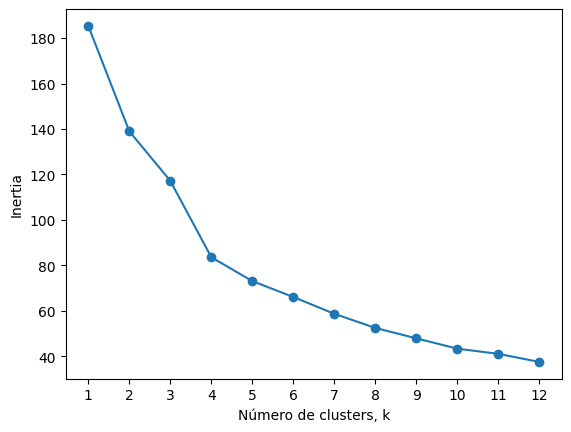

In [76]:
plt.plot(list(inertias.keys()),
         list(inertias.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Inertia')
plt.xticks(list(inertias.keys()))
plt.show()

**Cálculo de Silhouette**

In [77]:
# Silhouette

from sklearn.metrics import silhouette_score

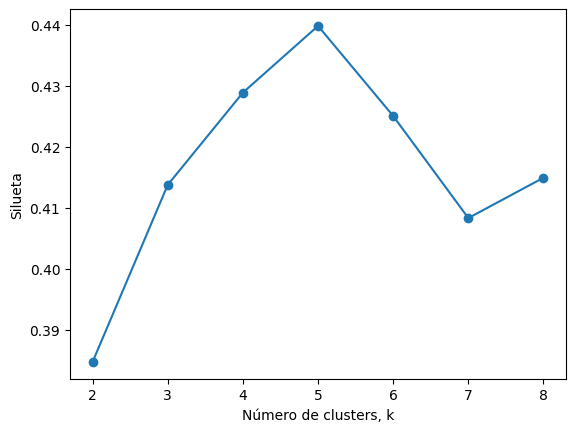

In [78]:
silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

# Determinar el mejor k

De acuerdo al método del codo (Inercia), la mayor disminución en la inercia ocurre entre k=3 y k=4, por lo que **k=4** podría ser el codo más pronunciado. Después de k=4, la disminución es menos significativa.

En el método de la silueta, el puntaje más alto se encuentra en **k=5**, seguido de **k=4**.

Considerando ambos métodos, y buscando un equilibrio entre la cohesión del cluster (baja inercia) y la distinción (alta silueta), **k=4 o k=5** son los candidatos más fuertes. k=4 presenta el 'codo' más fuerte y un buen puntaje de silueta, además tiene un buen puntaje de silueta.

Ya se realizaron los cálculos cuando k=3, a continuación de presentan los cálculos con k=4.

# Cálculo de K-Means con k=4

In [30]:
# Re-initialize and fit KMeans model with the updated X_train
model4 = KMeans(n_clusters=4, random_state=42, n_init=10) # Added random_state for reproducibility and n_init
model4.fit(X_train)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [79]:
# Calcular la inercia del modelo

model4.inertia_

83.58404860399305

In [80]:
model4.cluster_centers_

array([[0.00419397, 0.98306199, 0.79007368, 0.89661853],
       [0.00321669, 0.94784999, 0.79806774, 0.92750478],
       [0.0308041 , 0.74575016, 0.80779703, 0.61155464],
       [0.0223409 , 0.90044133, 0.78518225, 0.85971917]])

In [81]:
# Se obtienen los centroides
centroides4_df = (pd.DataFrame(model4.cluster_centers_)
.rename(columns={0:'V1', 1:'V2', 2:'V3', 3:'AmountE'}))
centroides4_df

,V1,V2,V3,AmountE
0,0.004194,0.983062,0.790074,0.896619
1,0.003217,0.947850,0.798068,0.927505
2,0.030804,0.745750,0.807797,0.611555
3,0.022341,0.900441,0.785182,0.859719


In [82]:
# Se grafican los centroides

fig = px.scatter_ternary(centroides4_df,
                         a="V2",
                         b="V2",
                         c="V3")

fig

In [83]:
#Se obtienen los parámetros del modelo
model4.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 10,
 'random_state': 42,
 'tol': 0.0001,
 'verbose': 0}

In [84]:
# Se obtienen los metadatos del modelo

model4.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

In [85]:
# Se obtiene el subconjuntos de datos para prueba

X_test = X_test.drop(['cluster'], axis=1)
X_test

,AmountE,V1E,V2E,V3E
23470,0.003459,0.954240,0.798109,0.897676
10758,0.000307,0.960323,0.798601,0.951209
52382,0.000483,0.942534,0.808196,0.900560
19323,0.000137,0.949624,0.797666,0.946721
3992,0.001376,0.941375,0.789196,0.942618
...,...,...,...,...
91519,0.022641,0.939640,0.787223,0.920064
35845,0.000203,0.946102,0.801222,0.953130
87696,0.000137,0.961590,0.805459,0.913166
5502,0.007362,0.942062,0.794257,0.958659


In [86]:
# Se realiza la prueba del modelo

labels = model4.predict(X_test)
labels

array([0, 1, 1, ..., 1, 1, 0], dtype=int32)

In [87]:
X_test['cluster'] = labels
X_test

,AmountE,V1E,V2E,V3E,cluster
23470,0.003459,0.954240,0.798109,0.897676,0
10758,0.000307,0.960323,0.798601,0.951209,1
52382,0.000483,0.942534,0.808196,0.900560,1
19323,0.000137,0.949624,0.797666,0.946721,1
3992,0.001376,0.941375,0.789196,0.942618,1
...,...,...,...,...,...
91519,0.022641,0.939640,0.787223,0.920064,1
35845,0.000203,0.946102,0.801222,0.953130,1
87696,0.000137,0.961590,0.805459,0.913166,1
5502,0.007362,0.942062,0.794257,0.958659,1


In [88]:
#Se analizan los resulados

# Añadir la columna 'Class' real de y_test a X_test para el análisis
X_test_with_class = X_test.copy()
X_test_with_class['Class'] = y_test

# Filtrar solo las transacciones fraudulentas (Class == 1)
fraud_in_clusters = X_test_with_class[X_test_with_class['Class'] == 1]

# Contar cuántas transacciones fraudulentas hay en cada cluster
fraud_distribution = fraud_in_clusters['cluster'].value_counts().sort_index()

print("Distribución de transacciones fraudulentas (Class == 1) por cluster:")
print(fraud_distribution)

# Determinar si pertenecen a un solo grupo o a varios
if len(fraud_distribution) == 1:
    print(f"\nTodas las transacciones fraudulentas pertenecen al cluster {fraud_distribution.index[0]}.")
elif len(fraud_distribution) > 1:
    print("\nLas transacciones fraudulentas se distribuyen en varios clusters.")
else:
    print("\nNo se encontraron transacciones fraudulentas en el conjunto de prueba.")

Distribución de transacciones fraudulentas (Class == 1) por cluster:
cluster
0    13
1     5
2    22
3    25
Name: count, dtype: int64

Las transacciones fraudulentas se distribuyen en varios clusters.


Lo anterior nos indica que la selección de k no es óptima, o un método de aprendizaje no supervisado no es adecuado.
También puede deberse a la naturaleza de los datos seleccionados.